In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import shap

print("EV Research Environment Ready")

EV Research Environment Ready



# MP-EVData Reproduction Project

## Dataset
MP-EVData: Station-level EV charging load data from a Chinese city (2024)

## Objective
Reproduce the empirical analysis:

1. Data documentation
2. Data cleaning
3. Feature engineering
4. EV charging load visualization
5. Peak-valley difference analysis
6. Load factor calculation
7. Machine learning analysis
8. TOU price response analysis

## Tools
Python, Pandas, NumPy, Matplotlib, Scikit-learn, SHAP

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")


In [4]:
charging = pd.read_excel(
    "../dataset/charging session.xlsx"
)

charging.head()

FileNotFoundError: [Errno 2] No such file or directory: '../dataset/charging session.xlsx'

In [5]:
import os

os.getcwd()


'C:\\Users\\Laptop Arena'

In [6]:
import pandas as pd

charging = pd.read_excel(
    r"D:\Dataset\Anmol-MP-EV\dataset\charging session.xlsx"
)

charging.head()




,Charging Prototypes,ID,Single-pile Power（kW）,Total Orders (in thousands),Capacity（kW）,Equipment Type,Price
0,Taxi Demonstration Station,A1,80.0,88.2,5000,DC,Time-of-Use Pricing
1,Taxi Demonstration Station,A2,60.0,230.0,4500,DC,Time-of-Use Pricing
2,Bus Depot,A3,120.0,54.8,2500,DC,Time-of-Use Pricing
3,Bus Depot,A4,150.0,99.4,12000,DC,Free
4,Residential Charging Station,A5,7.0,3.3,100,AC,Time-of-Use Pricing


In [7]:
charging.shape

(12, 7)

In [8]:
charging.tail()

,Charging Prototypes,ID,Single-pile Power（kW）,Total Orders (in thousands),Capacity（kW）,Equipment Type,Price
7,NaN,NaN,NaN,NaN,84,NaN,NaN
8,Battery Swapping Station,A7,2400.0,353.6,2000,Snap-fit Battery Swap,Time-of-Use Pricing
9,Battery Swapping Station,A8,60.0,8.2,1600,Bolt-on Battery Swap,Time-of-Use Pricing
10,Heavy-Duty Truck Logistics Station,A9,300.0,44.2,0,DC,Free
11,Heavy-Duty Truck Logistics Station,A10,120.0,13.0,35000,DC,Time-of-Use Pricing


In [9]:
charging

,Charging Prototypes,ID,Single-pile Power（kW）,Total Orders (in thousands),Capacity（kW）,Equipment Type,Price
0,Taxi Demonstration Station,A1,80.0,88.2,5000,DC,Time-of-Use Pricing
1,Taxi Demonstration Station,A2,60.0,230.0,4500,DC,Time-of-Use Pricing
2,Bus Depot,A3,120.0,54.8,2500,DC,Time-of-Use Pricing
3,Bus Depot,A4,150.0,99.4,12000,DC,Free
4,Residential Charging Station,A5,7.0,3.3,100,AC,Time-of-Use Pricing
5,Residential Charging Station,A6,7.0,12.7,56,AC,Time-of-Use Pricing
6,NaN,NaN,NaN,NaN,56,NaN,NaN
7,NaN,NaN,NaN,NaN,84,NaN,NaN
8,Battery Swapping Station,A7,2400.0,353.6,2000,Snap-fit Battery Swap,Time-of-Use Pricing
9,Battery Swapping Station,A8,60.0,8.2,1600,Bolt-on Battery Swap,Time-of-Use Pricing


In [10]:
station_info = charging.dropna(subset=["ID"])

station_info


,Charging Prototypes,ID,Single-pile Power（kW）,Total Orders (in thousands),Capacity（kW）,Equipment Type,Price
0,Taxi Demonstration Station,A1,80.0,88.2,5000,DC,Time-of-Use Pricing
1,Taxi Demonstration Station,A2,60.0,230.0,4500,DC,Time-of-Use Pricing
2,Bus Depot,A3,120.0,54.8,2500,DC,Time-of-Use Pricing
3,Bus Depot,A4,150.0,99.4,12000,DC,Free
4,Residential Charging Station,A5,7.0,3.3,100,AC,Time-of-Use Pricing
5,Residential Charging Station,A6,7.0,12.7,56,AC,Time-of-Use Pricing
8,Battery Swapping Station,A7,2400.0,353.6,2000,Snap-fit Battery Swap,Time-of-Use Pricing
9,Battery Swapping Station,A8,60.0,8.2,1600,Bolt-on Battery Swap,Time-of-Use Pricing
10,Heavy-Duty Truck Logistics Station,A9,300.0,44.2,0,DC,Free
11,Heavy-Duty Truck Logistics Station,A10,120.0,13.0,35000,DC,Time-of-Use Pricing


In [11]:
load_15min = pd.read_excel(
    r"D:\Dataset\Anmol-MP-EV\dataset\station-level load Profile 15min.xlsx"
)

load_15min.head()

,Charging Prototypes,ID,Single-pile Power（kW）,Total Orders (in thousands),Capacity（kW）,Equipment Type,Price
0,Taxi Demonstration Station,A1,80.0,88.2,5000,DC,Time-of-Use Pricing
1,Taxi Demonstration Station,A2,60.0,230.0,4500,DC,Time-of-Use Pricing
2,Bus Depot,A3,120.0,54.8,2500,DC,Time-of-Use Pricing
3,Bus Depot,A4,150.0,99.4,12000,DC,Free
4,Residential Charging Station,A5,7.0,3.3,100,AC,Time-of-Use Pricing


In [12]:
load_15min.shape

(12, 7)

In [13]:
load_15min.columns

Index(['Charging Prototypes', 'ID', 'Single-pile Power（kW）',
       ' Total Orders (in thousands)', 'Capacity（kW）', 'Equipment Type',
       'Price'],
      dtype='str')

In [14]:
import pandas as pd

excel_file = pd.ExcelFile(
    r"D:\Dataset\Anmol-MP-EV\dataset\station-level load Profile 15min.xlsx"
)

excel_file.sheet_names

['站点确定', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10']

In [15]:
load_A1 = pd.read_excel(
    r"D:\Dataset\Anmol-MP-EV\dataset\station-level load Profile 15min.xlsx",
    sheet_name="A1"
)

load_A1.head()

,datetime,power
0,2024-01-01 00:00:00,184.4
1,2024-01-01 00:15:00,115.4
2,2024-01-01 00:30:00,275.2
3,2024-01-01 00:45:00,238.7
4,2024-01-01 01:00:00,313.8


In [16]:
load_A1.shape

(35232, 2)

In [17]:
load_A1.columns

Index(['datetime', 'power'], dtype='str')

In [18]:
load_A1["datetime"] = pd.to_datetime(
    load_A1["datetime"]
)

load_A1.info()

<class 'pandas.DataFrame'>
RangeIndex: 35232 entries, 0 to 35231
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  35232 non-null  datetime64[us]
 1   power     35232 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 550.6 KB


In [19]:
load_A1["datetime"].min(), load_A1["datetime"].max()

(Timestamp('2024-01-01 00:00:00'), Timestamp('2025-01-01 23:45:00'))

In [20]:
load_A1["datetime"].duplicated().sum()

np.int64(0)

In [21]:
load_A1["power"].describe()

count    35232.000000
mean       269.163615
std        210.175250
min          0.000000
25%        115.800000
50%        217.600000
75%        368.900000
max       1688.900000
Name: power, dtype: float64

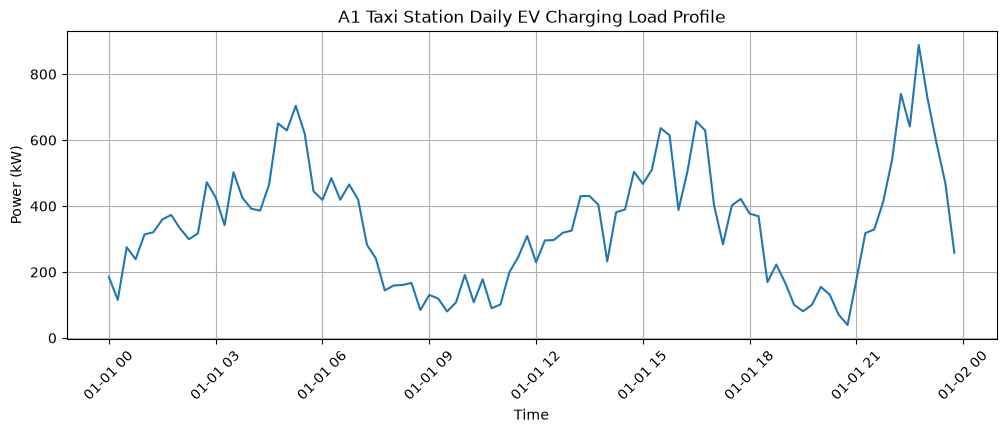

In [23]:
import matplotlib.pyplot as plt

day1 = load_A1[
    load_A1["datetime"].dt.date == 
    load_A1["datetime"].dt.date.iloc[0]
]

plt.figure(figsize=(12,4))

plt.plot(
    day1["datetime"],
    day1["power"]
)

plt.xlabel("Time")
plt.ylabel("Power (kW)")
plt.title("A1 Taxi Station Daily EV Charging Load Profile")

plt.xticks(rotation=45)
plt.grid(True)
plt.savefig(
    r"D:\Dataset\Anmol-MP-EV\figures\A1_daily_profile.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
peak = load_A1["power"].max()
valley = load_A1["power"].min()

peak_valley_difference = peak - valley

load_factor = load_A1["power"].mean() / peak

print("Peak Load:", peak, "kW")
print("Valley Load:", valley, "kW")
print("Peak-Valley Difference:", peak_valley_difference, "kW")
print("Load Factor:", load_factor)

Peak Load: 1688.9 kW
Valley Load: 0.0 kW
Peak-Valley Difference: 1688.9 kW
Load Factor: 0.1593721448654244


In [25]:
A1_features = pd.DataFrame({
    "Station": ["A1"],
    "Peak_Load_kW": [peak],
    "Valley_Load_kW": [valley],
    "Peak_Valley_Difference_kW": [peak_valley_difference],
    "Average_Load_kW": [load_A1["power"].mean()],
    "Load_Factor": [load_factor]
})

A1_features

,Station,Peak_Load_kW,Valley_Load_kW,Peak_Valley_Difference_kW,Average_Load_kW,Load_Factor
0,A1,1688.9,0.0,1688.9,269.163615,0.159372


In [27]:
stations = [
    "A1","A2","A3","A4","A5",
    "A6","A7","A8","A9","A10"
]

for station in stations:
    df = pd.read_excel(
        r"D:\Dataset\Anmol-MP-EV\dataset\station-level load Profile 15min.xlsx",
        sheet_name=station
    )
    
    print(station, df.columns.tolist())

A1 ['datetime', 'power']
A2 ['datetime', 'power']
A3 ['datetime', 'power']
A4 ['datetime', 'power']
A5 ['datetime', 'power']
A6 ['datetime', 'power']
A7 ['datetime', 'session_count']
A8 ['datetime', 'session_count']
A9 ['datetime', 'power']
A10 ['datetime', 'power']


In [29]:
stations = [
    "A1","A2","A3","A4","A5",
    "A6","A7","A8","A9","A10"
]

results = []

for station in stations:
    
    df = pd.read_excel(
        r"D:\Dataset\Anmol-MP-EV\dataset\station-level load Profile 15min.xlsx",
        sheet_name=station
    )

    df["datetime"] = pd.to_datetime(df["datetime"])
    
    # Charging stations
    if "power" in df.columns:
        
        peak = df["power"].max()
        valley = df["power"].min()
        avg = df["power"].mean()
        load_factor = avg / peak
        
        metric_type = "Power(kW)"
        
    # Battery swapping stations
    elif "session_count" in df.columns:
        
        peak = df["session_count"].max()
        valley = df["session_count"].min()
        avg = df["session_count"].mean()
        load_factor = avg / peak
        
        metric_type = "Session Count"

    results.append([
        station,
        metric_type,
        peak,
        valley,
        peak-valley,
        avg,
        load_factor
    ])


features = pd.DataFrame(
    results,
    columns=[
        "Station",
        "Metric_Type",
        "Peak",
        "Valley",
        "Peak_Valley_Difference",
        "Average",
        "Load_Factor"
    ]
)

features

,Station,Metric_Type,Peak,Valley,Peak_Valley_Difference,Average,Load_Factor
0,A1,Power(kW),1688.9,0.0,1688.9,269.163615,0.159372
1,A2,Power(kW),3020.3,0.0,3020.3,674.418259,0.223295
2,A3,Power(kW),3418.8,0.0,3418.8,576.626919,0.168664
3,A4,Power(kW),8896.8,0.0,8896.8,1239.017558,0.139266
4,A5,Power(kW),61.6,0.0,61.6,8.028525,0.130333
5,A6,Power(kW),103.8,0.0,103.8,25.036368,0.241198
6,A7,Session Count,256.0,0.0,256.0,3.336787,0.013034
7,A8,Session Count,3.0,0.0,3.0,0.250091,0.083364
8,A9,Power(kW),1099.2,0.0,1099.2,557.649174,0.507323
9,A10,Power(kW),1310.7,0.0,1310.7,167.038069,0.127442


In [31]:
features.to_csv(
    r"D:\Dataset\Anmol-MP-EV\processed_data\station_features.csv",
    index=False
)

In [32]:
station_features = features.merge(
    station_info[["ID", "Charging Prototypes"]],
    left_on="Station",
    right_on="ID",
    how="left"
)

station_features

,Station,Metric_Type,Peak,Valley,Peak_Valley_Difference,Average,Load_Factor,ID,Charging Prototypes
0,A1,Power(kW),1688.9,0.0,1688.9,269.163615,0.159372,A1,Taxi Demonstration Station
1,A2,Power(kW),3020.3,0.0,3020.3,674.418259,0.223295,A2,Taxi Demonstration Station
2,A3,Power(kW),3418.8,0.0,3418.8,576.626919,0.168664,A3,Bus Depot
3,A4,Power(kW),8896.8,0.0,8896.8,1239.017558,0.139266,A4,Bus Depot
4,A5,Power(kW),61.6,0.0,61.6,8.028525,0.130333,A5,Residential Charging Station
5,A6,Power(kW),103.8,0.0,103.8,25.036368,0.241198,A6,Residential Charging Station
6,A7,Session Count,256.0,0.0,256.0,3.336787,0.013034,A7,Battery Swapping Station
7,A8,Session Count,3.0,0.0,3.0,0.250091,0.083364,A8,Battery Swapping Station
8,A9,Power(kW),1099.2,0.0,1099.2,557.649174,0.507323,A9,Heavy-Duty Truck Logistics Station
9,A10,Power(kW),1310.7,0.0,1310.7,167.038069,0.127442,A10,Heavy-Duty Truck Logistics Station


In [33]:
station_features = station_features.rename(
    columns={
        "Charging Prototypes":"Station_Type"
    }
)

station_features

,Station,Metric_Type,Peak,Valley,Peak_Valley_Difference,Average,Load_Factor,ID,Station_Type
0,A1,Power(kW),1688.9,0.0,1688.9,269.163615,0.159372,A1,Taxi Demonstration Station
1,A2,Power(kW),3020.3,0.0,3020.3,674.418259,0.223295,A2,Taxi Demonstration Station
2,A3,Power(kW),3418.8,0.0,3418.8,576.626919,0.168664,A3,Bus Depot
3,A4,Power(kW),8896.8,0.0,8896.8,1239.017558,0.139266,A4,Bus Depot
4,A5,Power(kW),61.6,0.0,61.6,8.028525,0.130333,A5,Residential Charging Station
5,A6,Power(kW),103.8,0.0,103.8,25.036368,0.241198,A6,Residential Charging Station
6,A7,Session Count,256.0,0.0,256.0,3.336787,0.013034,A7,Battery Swapping Station
7,A8,Session Count,3.0,0.0,3.0,0.250091,0.083364,A8,Battery Swapping Station
8,A9,Power(kW),1099.2,0.0,1099.2,557.649174,0.507323,A9,Heavy-Duty Truck Logistics Station
9,A10,Power(kW),1310.7,0.0,1310.7,167.038069,0.127442,A10,Heavy-Duty Truck Logistics Station


In [38]:
station_features.to_csv(
    r"D:\Dataset\Anmol-MP-EV\processed_data\station_features_with_type.csv",
    index=False
)

In [39]:
station_features = station_features.drop(
    columns=["ID"]
)

station_features

,Station,Metric_Type,Peak,Valley,Peak_Valley_Difference,Average,Load_Factor,Station_Type
0,A1,Power(kW),1688.9,0.0,1688.9,269.163615,0.159372,Taxi Demonstration Station
1,A2,Power(kW),3020.3,0.0,3020.3,674.418259,0.223295,Taxi Demonstration Station
2,A3,Power(kW),3418.8,0.0,3418.8,576.626919,0.168664,Bus Depot
3,A4,Power(kW),8896.8,0.0,8896.8,1239.017558,0.139266,Bus Depot
4,A5,Power(kW),61.6,0.0,61.6,8.028525,0.130333,Residential Charging Station
5,A6,Power(kW),103.8,0.0,103.8,25.036368,0.241198,Residential Charging Station
6,A7,Session Count,256.0,0.0,256.0,3.336787,0.013034,Battery Swapping Station
7,A8,Session Count,3.0,0.0,3.0,0.250091,0.083364,Battery Swapping Station
8,A9,Power(kW),1099.2,0.0,1099.2,557.649174,0.507323,Heavy-Duty Truck Logistics Station
9,A10,Power(kW),1310.7,0.0,1310.7,167.038069,0.127442,Heavy-Duty Truck Logistics Station


In [40]:
station_features.to_csv(
    r"D:\Dataset\Anmol-MP-EV\processed_data\station_features_with_type.csv",
    index=False
)

In [41]:
import pandas as pd

file_path = r"D:\Dataset\Anmol-MP-EV\dataset\station-level load Profile 15min.xlsx"

daily_profiles = {}

for station in stations:

    df = pd.read_excel(
        file_path,
        sheet_name=station
    )

    df["datetime"] = pd.to_datetime(df["datetime"])

    df["date"] = df["datetime"].dt.date
    df["time"] = df["datetime"].dt.time

    if "power" in df.columns:
        value = "power"

    elif "session_count" in df.columns:
        value = "session_count"

    daily = df.pivot(
        index="date",
        columns="time",
        values=value
    )

    daily_profiles[station] = daily


daily_profiles["A1"].head()

time,00:00:00,00:15:00,00:30:00,00:45:00,01:00:00,01:15:00,01:30:00,01:45:00,02:00:00,02:15:00,...,21:30:00,21:45:00,22:00:00,22:15:00,22:30:00,22:45:00,23:00:00,23:15:00,23:30:00,23:45:00
date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,184.4,115.4,275.2,238.7,313.8,320.6,359.3,373.1,331.7,299.4,...,329.1,412.5,539.6,740.4,641.0,888.4,725.0,590.7,467.8,258.3
2024-01-02,692.9,595.9,757.2,695.0,631.7,795.2,733.2,507.5,456.7,458.0,...,490.4,584.2,933.6,830.0,924.8,881.0,625.5,787.8,1096.3,621.9
2024-01-03,907.0,874.2,693.3,644.0,610.9,611.9,627.0,475.0,533.8,433.2,...,392.8,547.1,926.4,1152.1,1193.6,1208.0,825.5,756.1,792.5,436.8
2024-01-04,836.6,741.4,805.7,762.6,564.0,499.5,550.5,399.4,237.9,194.5,...,294.9,353.0,701.8,987.4,1090.5,1045.7,1006.6,900.9,807.0,418.3
2024-01-05,940.8,955.0,868.1,768.3,613.3,477.9,506.8,513.9,375.8,411.5,...,485.7,401.8,838.1,1129.9,989.1,582.8,787.7,836.1,970.0,591.8


In [42]:
all_daily_profiles = []

for station, df in daily_profiles.items():

    temp = df.copy()

    temp["Station"] = station
    temp["Date"] = temp.index

    all_daily_profiles.append(temp)


daily_dataset = pd.concat(all_daily_profiles)

daily_dataset.head()

time,00:00:00,00:15:00,00:30:00,00:45:00,01:00:00,01:15:00,01:30:00,01:45:00,02:00:00,02:15:00,...,22:00:00,22:15:00,22:30:00,22:45:00,23:00:00,23:15:00,23:30:00,23:45:00,Station,Date
date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,184.4,115.4,275.2,238.7,313.8,320.6,359.3,373.1,331.7,299.4,...,539.6,740.4,641.0,888.4,725.0,590.7,467.8,258.3,A1,2024-01-01
2024-01-02,692.9,595.9,757.2,695.0,631.7,795.2,733.2,507.5,456.7,458.0,...,933.6,830.0,924.8,881.0,625.5,787.8,1096.3,621.9,A1,2024-01-02
2024-01-03,907.0,874.2,693.3,644.0,610.9,611.9,627.0,475.0,533.8,433.2,...,926.4,1152.1,1193.6,1208.0,825.5,756.1,792.5,436.8,A1,2024-01-03
2024-01-04,836.6,741.4,805.7,762.6,564.0,499.5,550.5,399.4,237.9,194.5,...,701.8,987.4,1090.5,1045.7,1006.6,900.9,807.0,418.3,A1,2024-01-04
2024-01-05,940.8,955.0,868.1,768.3,613.3,477.9,506.8,513.9,375.8,411.5,...,838.1,1129.9,989.1,582.8,787.7,836.1,970.0,591.8,A1,2024-01-05


In [43]:
daily_dataset.to_csv(
    r"D:\Dataset\Anmol-MP-EV\processed_data\daily_load_profiles.csv",
    index=False
)

In [44]:
daily_dataset.columns

Index([ 00:00:00,  00:15:00,  00:30:00,  00:45:00,  01:00:00,  01:15:00,
        01:30:00,  01:45:00,  02:00:00,  02:15:00,  02:30:00,  02:45:00,
        03:00:00,  03:15:00,  03:30:00,  03:45:00,  04:00:00,  04:15:00,
        04:30:00,  04:45:00,  05:00:00,  05:15:00,  05:30:00,  05:45:00,
        06:00:00,  06:15:00,  06:30:00,  06:45:00,  07:00:00,  07:15:00,
        07:30:00,  07:45:00,  08:00:00,  08:15:00,  08:30:00,  08:45:00,
        09:00:00,  09:15:00,  09:30:00,  09:45:00,  10:00:00,  10:15:00,
        10:30:00,  10:45:00,  11:00:00,  11:15:00,  11:30:00,  11:45:00,
        12:00:00,  12:15:00,  12:30:00,  12:45:00,  13:00:00,  13:15:00,
        13:30:00,  13:45:00,  14:00:00,  14:15:00,  14:30:00,  14:45:00,
        15:00:00,  15:15:00,  15:30:00,  15:45:00,  16:00:00,  16:15:00,
        16:30:00,  16:45:00,  17:00:00,  17:15:00,  17:30:00,  17:45:00,
        18:00:00,  18:15:00,  18:30:00,  18:45:00,  19:00:00,  19:15:00,
        19:30:00,  19:45:00,  20:00:00,  20:15:00, 

In [45]:
X = daily_dataset.drop(
    columns=["Station", "Date"]
)

X.head()

time,00:00:00,00:15:00,00:30:00,00:45:00,01:00:00,01:15:00,01:30:00,01:45:00,02:00:00,02:15:00,...,21:30:00,21:45:00,22:00:00,22:15:00,22:30:00,22:45:00,23:00:00,23:15:00,23:30:00,23:45:00
date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,184.4,115.4,275.2,238.7,313.8,320.6,359.3,373.1,331.7,299.4,...,329.1,412.5,539.6,740.4,641.0,888.4,725.0,590.7,467.8,258.3
2024-01-02,692.9,595.9,757.2,695.0,631.7,795.2,733.2,507.5,456.7,458.0,...,490.4,584.2,933.6,830.0,924.8,881.0,625.5,787.8,1096.3,621.9
2024-01-03,907.0,874.2,693.3,644.0,610.9,611.9,627.0,475.0,533.8,433.2,...,392.8,547.1,926.4,1152.1,1193.6,1208.0,825.5,756.1,792.5,436.8
2024-01-04,836.6,741.4,805.7,762.6,564.0,499.5,550.5,399.4,237.9,194.5,...,294.9,353.0,701.8,987.4,1090.5,1045.7,1006.6,900.9,807.0,418.3
2024-01-05,940.8,955.0,868.1,768.3,613.3,477.9,506.8,513.9,375.8,411.5,...,485.7,401.8,838.1,1129.9,989.1,582.8,787.7,836.1,970.0,591.8


In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled.shape

(3376, 96)

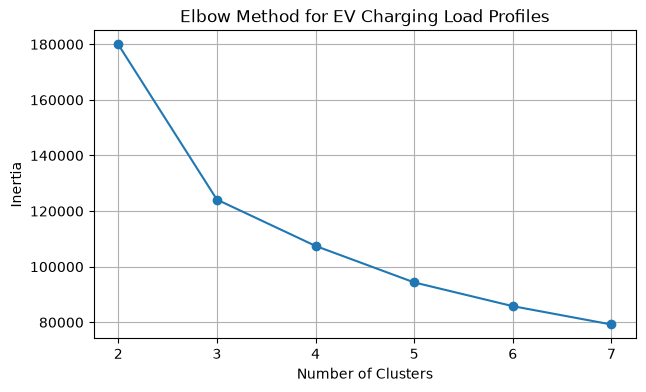

In [47]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2,8):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(7,4))
plt.plot(range(2,8), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for EV Charging Load Profiles")
plt.grid(True)
plt.show()

In [48]:
plt.savefig(
    r"D:\Dataset\Anmol-MP-EV\figures\elbow_method_kmeans.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

In [49]:
elbow_results = pd.DataFrame({
    "Clusters": range(2,8),
    "Inertia": inertia
})

elbow_results.to_csv(
    r"D:\Dataset\Anmol-MP-EV\processed_data\kmeans_elbow_results.csv",
    index=False
)

In [50]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

clusters[:10]

array([0, 1, 1, 1, 1, 1, 1, 0, 1, 1], dtype=int32)

In [51]:
daily_clustered = daily_dataset.copy()

daily_clustered["Cluster"] = clusters

daily_clustered.head()

time,00:00:00,00:15:00,00:30:00,00:45:00,01:00:00,01:15:00,01:30:00,01:45:00,02:00:00,02:15:00,...,22:15:00,22:30:00,22:45:00,23:00:00,23:15:00,23:30:00,23:45:00,Station,Date,Cluster
date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,184.4,115.4,275.2,238.7,313.8,320.6,359.3,373.1,331.7,299.4,...,740.4,641.0,888.4,725.0,590.7,467.8,258.3,A1,2024-01-01,0
2024-01-02,692.9,595.9,757.2,695.0,631.7,795.2,733.2,507.5,456.7,458.0,...,830.0,924.8,881.0,625.5,787.8,1096.3,621.9,A1,2024-01-02,1
2024-01-03,907.0,874.2,693.3,644.0,610.9,611.9,627.0,475.0,533.8,433.2,...,1152.1,1193.6,1208.0,825.5,756.1,792.5,436.8,A1,2024-01-03,1
2024-01-04,836.6,741.4,805.7,762.6,564.0,499.5,550.5,399.4,237.9,194.5,...,987.4,1090.5,1045.7,1006.6,900.9,807.0,418.3,A1,2024-01-04,1
2024-01-05,940.8,955.0,868.1,768.3,613.3,477.9,506.8,513.9,375.8,411.5,...,1129.9,989.1,582.8,787.7,836.1,970.0,591.8,A1,2024-01-05,1


In [52]:
daily_clustered.to_csv(
    r"D:\Dataset\Anmol-MP-EV\processed_data\kmeans_cluster_results.csv",
    index=False
)

In [53]:
# Calculate average charging profile for each cluster

cluster_profiles = daily_clustered.groupby("Cluster").mean(numeric_only=True)

cluster_profiles

time,00:00:00,00:15:00,00:30:00,00:45:00,01:00:00,01:15:00,01:30:00,01:45:00,02:00:00,02:15:00,...,21:30:00,21:45:00,22:00:00,22:15:00,22:30:00,22:45:00,23:00:00,23:15:00,23:30:00,23:45:00
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1354.359441,1372.442021,1332.960771,1226.208910,1138.973404,1060.898404,996.771011,921.513165,857.658112,791.256383,...,544.321941,582.180718,861.159973,980.098138,1022.998005,1025.515293,1012.009176,1031.453590,1084.821410,600.185638
1,396.296753,401.222259,400.540000,390.877129,367.950306,344.391671,315.935012,280.910729,240.885976,196.378871,...,70.469882,84.938965,362.841082,392.318165,398.551671,402.607812,392.876800,368.271765,359.784800,193.783294
2,4808.190180,4910.828457,5070.912625,5409.517234,5639.338076,5465.403808,5097.442685,4519.921443,3815.315030,3039.308216,...,458.284369,1290.731463,5695.660321,5930.502204,5975.975150,5947.139078,5825.319840,5520.729459,5008.232465,2993.183768


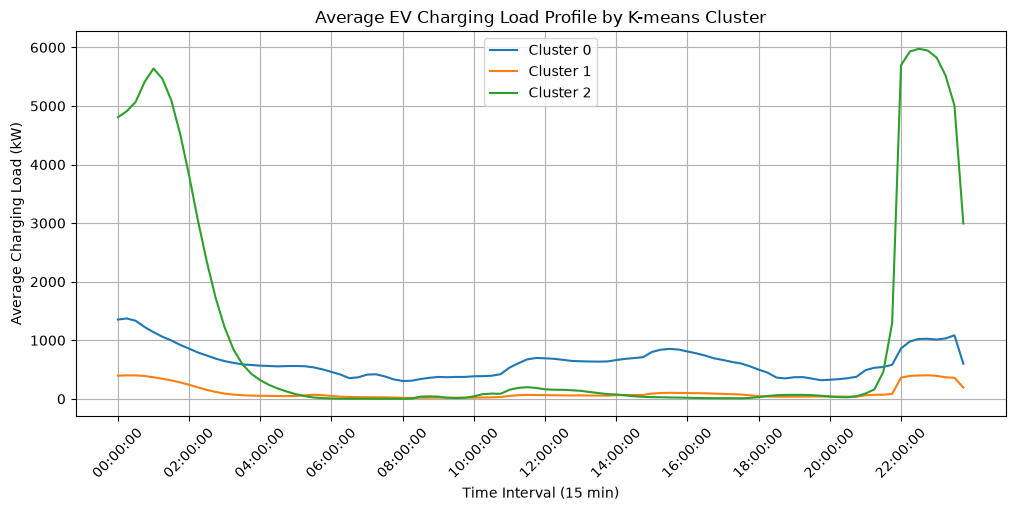

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

for cluster in cluster_profiles.index:
    plt.plot(
        range(len(cluster_profiles.columns)),
        cluster_profiles.loc[cluster],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Time Interval (15 min)")
plt.ylabel("Average Charging Load (kW)")
plt.title("Average EV Charging Load Profile by K-means Cluster")

plt.xticks(
    range(0,96,8),
    cluster_profiles.columns[::8],
    rotation=45
)

plt.legend()
plt.grid(True)

plt.savefig(
    r"D:\Dataset\Anmol-MP-EV\figures\kmeans_cluster_profiles.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
# Cluster size distribution

cluster_counts = pd.Series(clusters).value_counts().sort_index()

cluster_distribution = pd.DataFrame({
    "Cluster": cluster_counts.index,
    "Number_of_Profiles": cluster_counts.values
})

cluster_distribution

,Cluster,Number_of_Profiles
0,0,752
1,1,2125
2,2,499


In [57]:
cluster_distribution.to_csv(
    r"D:\Dataset\Anmol-MP-EV\processed_data\cluster_distribution.csv",
    index=False
)

In [58]:
cluster_characteristics = cluster_profiles.copy()

cluster_characteristics["Average_Load_kW"] = cluster_profiles.mean(axis=1)
cluster_characteristics["Peak_Load_kW"] = cluster_profiles.max(axis=1)
cluster_characteristics["Minimum_Load_kW"] = cluster_profiles.min(axis=1)

cluster_characteristics

time,00:00:00,00:15:00,00:30:00,00:45:00,01:00:00,01:15:00,01:30:00,01:45:00,02:00:00,02:15:00,...,22:15:00,22:30:00,22:45:00,23:00:00,23:15:00,23:30:00,23:45:00,Average_Load_kW,Peak_Load_kW,Minimum_Load_kW
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1354.359441,1372.442021,1332.960771,1226.208910,1138.973404,1060.898404,996.771011,921.513165,857.658112,791.256383,...,980.098138,1022.998005,1025.515293,1012.009176,1031.453590,1084.821410,600.185638,629.005715,1372.442021,304.202261
1,396.296753,401.222259,400.540000,390.877129,367.950306,344.391671,315.935012,280.910729,240.885976,196.378871,...,392.318165,398.551671,402.607812,392.876800,368.271765,359.784800,193.783294,109.515802,402.607812,16.484000
2,4808.190180,4910.828457,5070.912625,5409.517234,5639.338076,5465.403808,5097.442685,4519.921443,3815.315030,3039.308216,...,5930.502204,5975.975150,5947.139078,5825.319840,5520.729459,5008.232465,2993.183768,1084.591017,5975.975150,0.892585


In [59]:
cluster_characteristics.to_csv(
    r"D:\Dataset\Anmol-MP-EV\processed_data\cluster_characteristics.csv",
    index=True
)

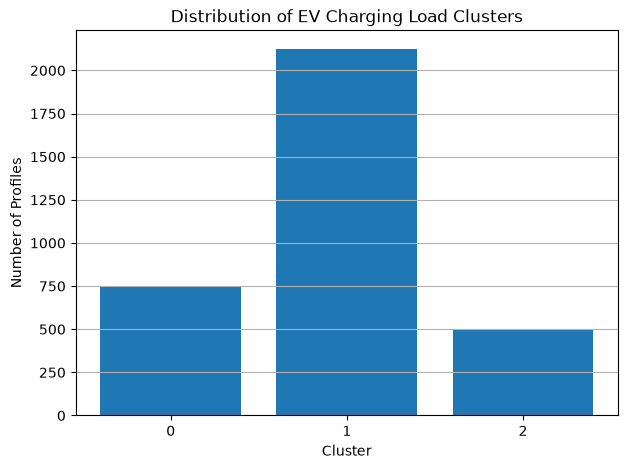

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(
    cluster_distribution["Cluster"].astype(str),
    cluster_distribution["Number_of_Profiles"]
)

plt.xlabel("Cluster")
plt.ylabel("Number of Profiles")
plt.title("Distribution of EV Charging Load Clusters")

plt.grid(axis="y")

plt.savefig(
    r"D:\Dataset\Anmol-MP-EV\figures\cluster_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [61]:
# Create final ML summary table

ml_summary = pd.DataFrame({
    "Cluster": cluster_profiles.index,
    "Average_Load_kW": cluster_profiles.mean(axis=1).values,
    "Peak_Load_kW": cluster_profiles.max(axis=1).values,
    "Minimum_Load_kW": cluster_profiles.min(axis=1).values
})

# Add number of profiles in each cluster
ml_summary["Number_of_Profiles"] = cluster_distribution["Number_of_Profiles"].values

# Add interpretation
ml_summary["Load_Pattern"] = [
    "Moderate charging demand",
    "Low utilization charging pattern",
    "High-intensity commercial charging"
]

ml_summary

,Cluster,Average_Load_kW,Peak_Load_kW,Minimum_Load_kW,Number_of_Profiles,Load_Pattern
0,0,629.005715,1372.442021,304.202261,752,Moderate charging demand
1,1,109.515802,402.607812,16.484000,2125,Low utilization charging pattern
2,2,1084.591017,5975.975150,0.892585,499,High-intensity commercial charging


In [62]:
ml_summary.to_csv(
    r"D:\Dataset\Anmol-MP-EV\processed_data\ML_results_summary.csv",
    index=False
)

In [63]:
price = pd.read_excel(
    r"D:\Dataset\Anmol-MP-EV\dataset\price.xlsx"
)

price.head()

,Charging Prototypes,ID,Single-pile Power（kW）,Total Orders (in thousands),Capacity（kW）,Equipment Type,Price
0,Taxi Demonstration Station,A1,80.0,88.2,5000,DC,Time-of-Use Pricing
1,Taxi Demonstration Station,A2,60.0,230.0,4500,DC,Time-of-Use Pricing
2,Bus Depot,A3,120.0,54.8,2500,DC,Time-of-Use Pricing
3,Bus Depot,A4,150.0,99.4,12000,DC,Free
4,Residential Charging Station,A5,7.0,3.3,100,AC,Time-of-Use Pricing


In [64]:
price_excel = pd.ExcelFile(
    r"D:\Dataset\Anmol-MP-EV\dataset\price.xlsx"
)

price_excel.sheet_names

['站点确定', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10']

In [65]:
price_A1 = pd.read_excel(
    r"D:\Dataset\Anmol-MP-EV\dataset\price.xlsx",
    sheet_name="A1"
)

price_A1.head()

,Month,Period,Total Price(RMB),Electricity Price(RMB),Service Price(RMB)
0,1,Sharp(19:00-21:00),1.80,1.3648,0.4352
1,1,"Peak(08:00-11:00,18:00-21:00)",1.35,1.1142,0.2358
2,1,"Shoulder(06:00-08:00,11:00-18:00,21:00-22:00)",1.15,0.6687,0.4813
3,1,"Off-peak(00:00-06:00,22:00-00:00)",0.95,0.3345,0.6155
4,2,"Peak(08:00-11:00,18:00-21:00)",1.35,1.0321,0.3179


In [66]:
price_A1.shape

(40, 5)

In [67]:
import pandas as pd

def classify_tou(hour):
    if 19 <= hour < 21:
        return "Sharp"
    elif (8 <= hour < 11) or (18 <= hour < 21):
        return "Peak"
    elif (6 <= hour < 8) or (11 <= hour < 18) or (21 <= hour < 22):
        return "Shoulder"
    else:
        return "Off-peak"


load_A1["hour"] = load_A1["datetime"].dt.hour

load_A1["TOU_period"] = load_A1["hour"].apply(classify_tou)

load_A1.head()

,datetime,power,hour,TOU_period
0,2024-01-01 00:00:00,184.4,0,Off-peak
1,2024-01-01 00:15:00,115.4,0,Off-peak
2,2024-01-01 00:30:00,275.2,0,Off-peak
3,2024-01-01 00:45:00,238.7,0,Off-peak
4,2024-01-01 01:00:00,313.8,1,Off-peak


In [68]:
tou_response_A1 = (
    load_A1.groupby("TOU_period")["power"]
    .agg(["mean","max","sum"])
    .reset_index()
)

tou_response_A1

,TOU_period,mean,max,sum
0,Off-peak,360.881880,1688.9,4238196.8
1,Peak,107.418852,753.6,630763.5
2,Sharp,132.129598,587.9,387932.5
3,Shoulder,287.893713,1413.2,4226279.7


In [69]:
tou_response_A1.to_csv(
    r"D:\Dataset\Anmol-MP-EV\processed_data\TOU_response_A1.csv",
    index=False
)

In [70]:
stations = ["A1","A2","A3","A4","A5",
            "A6","A7","A8","A9","A10"]

all_tou_results = []

for station in stations:

    df = pd.read_excel(
        r"D:\Dataset\Anmol-MP-EV\dataset\station-level load Profile 15min.xlsx",
        sheet_name=station
    )

    # Handle A7/A8 session count difference
    value_col = df.columns[1]

    df["datetime"] = pd.to_datetime(df["datetime"])
    df["hour"] = df["datetime"].dt.hour

    df["TOU_period"] = df["hour"].apply(classify_tou)

    result = (
        df.groupby("TOU_period")[value_col]
        .mean()
        .reset_index()
    )

    result["Station"] = station
    result.rename(
        columns={value_col:"Average_Load"},
        inplace=True
    )

    all_tou_results.append(result)


tou_all = pd.concat(all_tou_results)

tou_all.head()

,TOU_period,Average_Load,Station
0,Off-peak,360.881880,A1
1,Peak,107.418852,A1
2,Sharp,132.129598,A1
3,Shoulder,287.893713,A1
0,Off-peak,1008.384077,A2


In [71]:
tou_all.to_csv(
    r"D:\Dataset\Anmol-MP-EV\processed_data\TOU_all_stations.csv",
    index=False
)

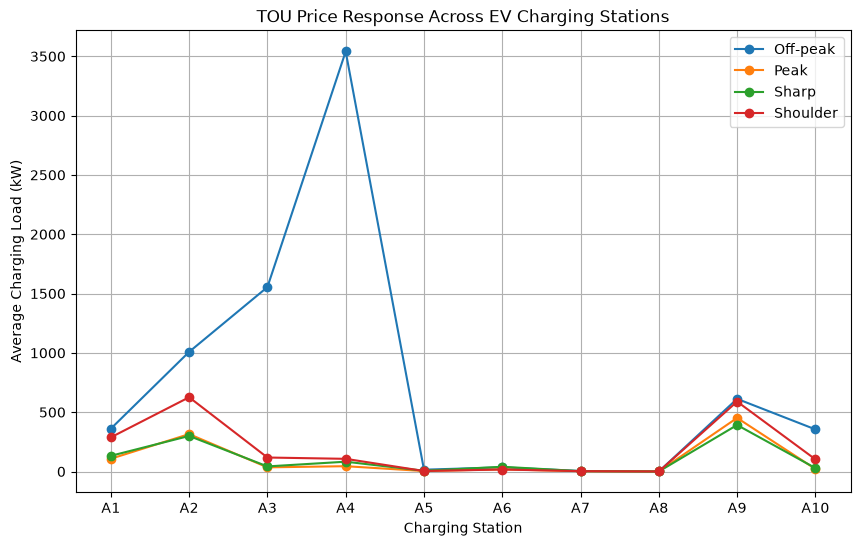

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for period in tou_all["TOU_period"].unique():
    temp = tou_all[tou_all["TOU_period"] == period]
    
    plt.plot(
        temp["Station"],
        temp["Average_Load"],
        marker="o",
        label=period
    )

plt.xlabel("Charging Station")
plt.ylabel("Average Charging Load (kW)")
plt.title("TOU Price Response Across EV Charging Stations")

plt.legend()
plt.grid(True)

plt.savefig(
    r"D:\Dataset\Anmol-MP-EV\figures\TOU_response_all_stations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [73]:
stations = ["A1","A2","A3","A4","A5","A6","A7","A8","A9","A10"]

tou_results = []

for station in stations:

    df = pd.read_excel(
        r"D:\Dataset\Anmol-MP-EV\dataset\station-level load Profile 15min.xlsx",
        sheet_name=station
    )

    df["datetime"] = pd.to_datetime(df["datetime"])

    # Some stations have session_count instead of power
    if "power" not in df.columns:
        continue

    df["hour"] = df["datetime"].dt.hour


    # Define TOU periods
    def assign_tou(hour):
        if 0 <= hour < 6 or hour >= 22:
            return "Off-peak"
        elif (8 <= hour < 11) or (18 <= hour < 21):
            return "Peak"
        elif (19 <= hour < 21):
            return "Sharp"
        else:
            return "Shoulder"


    df["TOU_period"] = df["hour"].apply(assign_tou)


    result = (
        df.groupby("TOU_period")["power"]
        .agg(["mean","max","sum"])
        .reset_index()
    )

    result["Station"] = station

    tou_results.append(result)


tou_all = pd.concat(tou_results)

tou_all.head()

,TOU_period,mean,max,sum,Station
0,Off-peak,360.881880,1688.9,4238196.8,A1
1,Peak,115.655767,753.6,1018696.0,A1
2,Shoulder,287.893713,1413.2,4226279.7,A1
0,Off-peak,1008.384077,3020.3,11842462.6,A2
1,Peak,310.047446,911.2,2730897.9,A2


In [74]:
tou_all.to_csv(
    r"D:\Dataset\Anmol-MP-EV\processed_data\TOU_response_all_stations.csv",
    index=False
)

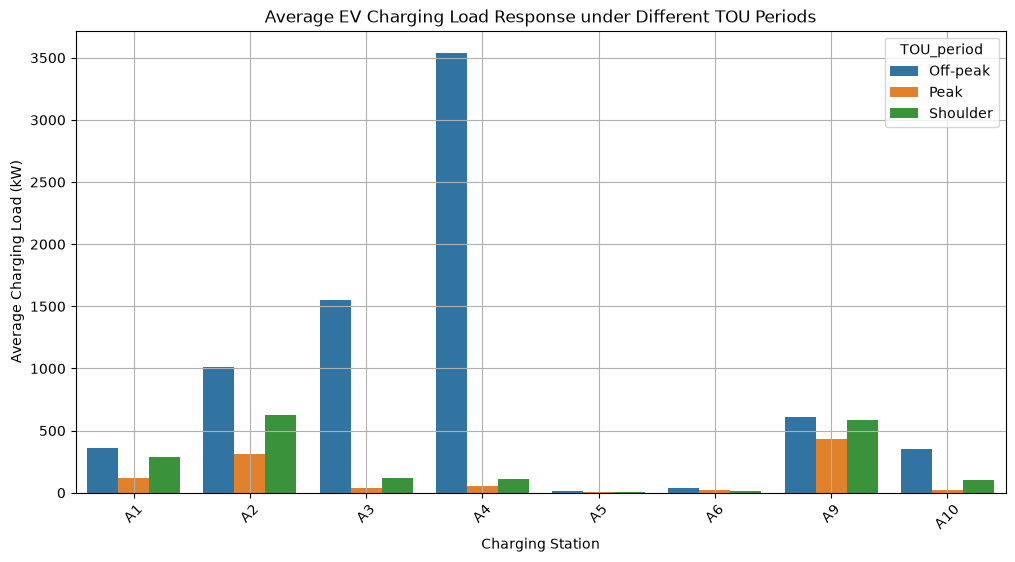

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=tou_all,
    x="Station",
    y="mean",
    hue="TOU_period"
)

plt.title("Average EV Charging Load Response under Different TOU Periods")
plt.xlabel("Charging Station")
plt.ylabel("Average Charging Load (kW)")
plt.xticks(rotation=45)
plt.grid(True)

plt.savefig(
    r"D:\Dataset\Anmol-MP-EV\figures\TOU_response_all_stations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [76]:
import pandas as pd

stations = ["A1","A2","A3","A4","A5","A6","A9","A10"]

combined_load = []

for station in stations:

    df = pd.read_excel(
        r"D:\Dataset\Anmol-MP-EV\dataset\station-level load Profile 15min.xlsx",
        sheet_name=station
    )

    df["datetime"] = pd.to_datetime(df["datetime"])

    df = df[["datetime","power"]]

    df.columns = ["datetime", station]

    combined_load.append(df)


# Merge all stations by time

system_load = combined_load[0]

for df in combined_load[1:]:
    system_load = system_load.merge(
        df,
        on="datetime",
        how="outer"
    )


system_load = system_load.fillna(0)


# Total system load

system_load["Total_Load_kW"] = (
    system_load[stations]
    .sum(axis=1)
)


# Number of active stations

system_load["Active_Stations"] = (
    (system_load[stations] > 0)
    .sum(axis=1)
)


system_load.head()

,datetime,A1,A2,A3,A4,A5,A6,A9,A10,Total_Load_kW,Active_Stations
0,2024-01-01 00:00:00,184.4,495.2,424.3,2447.8,0.0,0.0,294.4,0.0,3846.1,5
1,2024-01-01 00:15:00,115.4,960.9,778.5,3644.2,0.0,0.0,432.7,0.0,5931.7,5
2,2024-01-01 00:30:00,275.2,1213.5,932.2,4355.9,0.0,0.0,720.1,0.0,7496.9,5
3,2024-01-01 00:45:00,238.7,1318.4,1214.3,5296.1,0.0,0.0,888.5,0.0,8956.0,5
4,2024-01-01 01:00:00,313.8,1303.7,1721.4,5291.6,0.0,1.0,854.6,0.0,9486.1,6


In [77]:
system_load.to_csv(
    r"D:\Dataset\Anmol-MP-EV\processed_data\simultaneity_analysis.csv",
    index=False
)

In [78]:
max_load_time = system_load.loc[
    system_load["Total_Load_kW"].idxmax()
]

max_active_time = system_load.loc[
    system_load["Active_Stations"].idxmax()
]

print("Maximum Total Load:")
print(max_load_time)

print("\nMaximum Active Stations:")
print(max_active_time)

Maximum Total Load:
datetime           2024-12-11 23:15:00
A1                              1053.1
A2                              2321.6
A3                              2663.2
A4                              7865.3
A5                                42.1
A6                                80.4
A9                               727.5
A10                              981.4
Total_Load_kW                  15734.6
Active_Stations                      8
Name: 33213, dtype: object

Maximum Active Stations:
datetime           2024-09-28 01:45:00
A1                               287.3
A2                              1437.2
A3                              1905.4
A4                              5828.2
A5                                23.3
A6                                31.7
A9                               675.7
A10                               34.9
Total_Load_kW                  10223.7
Active_Stations                      8
Name: 26023, dtype: object


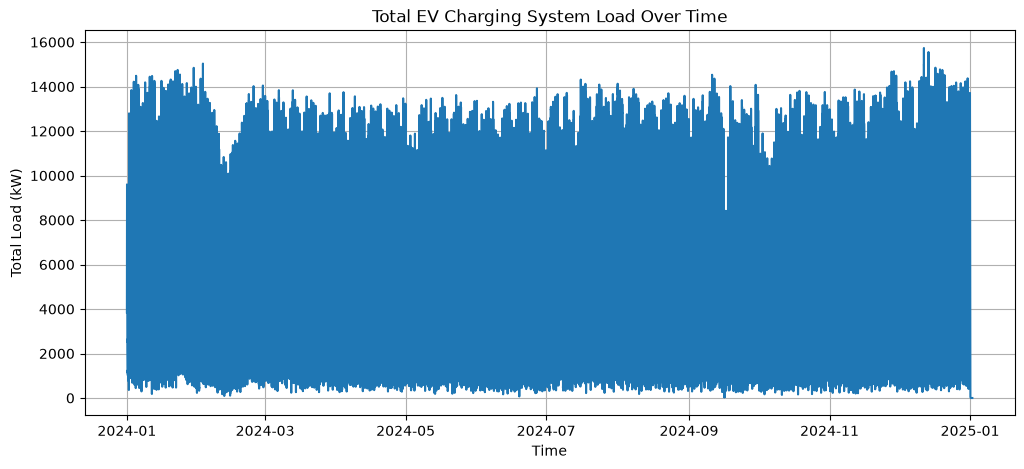

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    system_load["datetime"],
    system_load["Total_Load_kW"]
)

plt.title("Total EV Charging System Load Over Time")
plt.xlabel("Time")
plt.ylabel("Total Load (kW)")
plt.grid(True)

plt.savefig(
    r"D:\Dataset\Anmol-MP-EV\figures\system_total_load_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [80]:
plt.savefig(
    r"D:\Dataset\Anmol-MP-EV\figures\system_total_load_curve.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [81]:
max_load_time = system_load.loc[
    system_load["Total_Load_kW"].idxmax()
]

max_active_time = system_load.loc[
    system_load["Active_Stations"].idxmax()
]

print("Maximum Total Load:")
print(max_load_time)

print("\nMaximum Active Stations:")
print(max_active_time)

Maximum Total Load:
datetime           2024-12-11 23:15:00
A1                              1053.1
A2                              2321.6
A3                              2663.2
A4                              7865.3
A5                                42.1
A6                                80.4
A9                               727.5
A10                              981.4
Total_Load_kW                  15734.6
Active_Stations                      8
Name: 33213, dtype: object

Maximum Active Stations:
datetime           2024-09-28 01:45:00
A1                               287.3
A2                              1437.2
A3                              1905.4
A4                              5828.2
A5                                23.3
A6                                31.7
A9                               675.7
A10                               34.9
Total_Load_kW                  10223.7
Active_Stations                      8
Name: 26023, dtype: object


In [82]:
import pandas as pd

# Load station feature dataset
ml_data = pd.read_csv(
    r"D:\Dataset\Anmol-MP-EV\processed_data\station_features_with_type.csv"
)

ml_data.head()

,Station,Metric_Type,Peak,Valley,Peak_Valley_Difference,Average,Load_Factor,Station_Type
0,A1,Power(kW),1688.9,0.0,1688.9,269.163615,0.159372,Taxi Demonstration Station
1,A2,Power(kW),3020.3,0.0,3020.3,674.418259,0.223295,Taxi Demonstration Station
2,A3,Power(kW),3418.8,0.0,3418.8,576.626919,0.168664,Bus Depot
3,A4,Power(kW),8896.8,0.0,8896.8,1239.017558,0.139266,Bus Depot
4,A5,Power(kW),61.6,0.0,61.6,8.028525,0.130333,Residential Charging Station


In [83]:
features = [
    "Peak",
    "Valley",
    "Peak_Valley_Difference",
    "Average",
    "Load_Factor"
]


X = ml_data[features]

y = ml_data["Station_Type"]

X.head()

,Peak,Valley,Peak_Valley_Difference,Average,Load_Factor
0,1688.9,0.0,1688.9,269.163615,0.159372
1,3020.3,0.0,3020.3,674.418259,0.223295
2,3418.8,0.0,3418.8,576.626919,0.168664
3,8896.8,0.0,8896.8,1239.017558,0.139266
4,61.6,0.0,61.6,8.028525,0.130333


In [84]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print(encoder.classes_)

['Battery Swapping Station' 'Bus Depot'
 'Heavy-Duty Truck Logistics Station' 'Residential Charging Station'
 'Taxi Demonstration Station']


In [86]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        prediction,
        labels=sorted(set(y_test)),
        target_names=[
            encoder.classes_[i] 
            for i in sorted(set(y_test))
        ]
    )
)

                                    precision    recall  f1-score   support

Heavy-Duty Truck Logistics Station       0.00      0.00      0.00         1
      Residential Charging Station       1.00      1.00      1.00         1
        Taxi Demonstration Station       0.00      0.00      0.00         1

                         micro avg       0.50      0.33      0.40         3
                         macro avg       0.33      0.33      0.33         3
                      weighted avg       0.33      0.33      0.33         3



C:\Users\Laptop Arena\anaconda3\envs\evresearch\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Laptop Arena\anaconda3\envs\evresearch\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Laptop Arena\anaconda3\envs\evresearch\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

In [87]:
import matplotlib.pyplot as plt
import pandas as pd


importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})


importance = importance.sort_values(
    by="Importance",
    ascending=False
)


importance

,Feature,Importance
3,Average,0.274189
4,Load_Factor,0.273363
2,Peak_Valley_Difference,0.235204
0,Peak,0.217244
1,Valley,0.000000


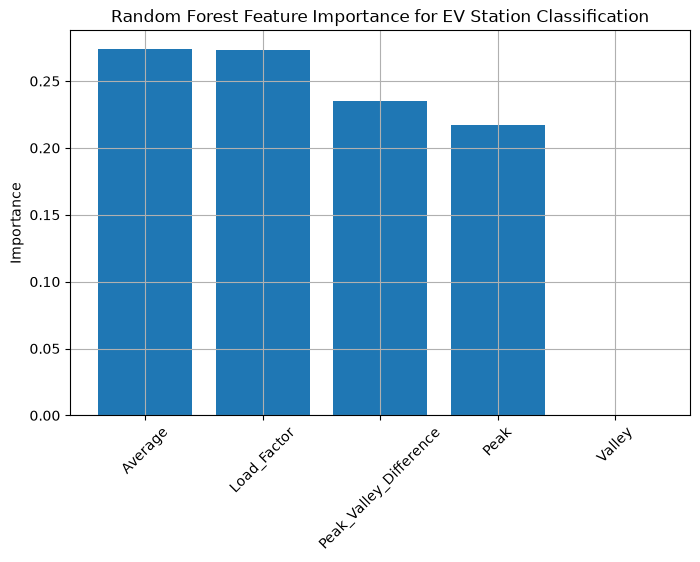

In [88]:
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance for EV Station Classification")
plt.ylabel("Importance")
plt.xticks(rotation=45)

plt.grid(True)

plt.savefig(
    r"D:\Dataset\Anmol-MP-EV\figures\RF_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [89]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
3,Average,0.274189
4,Load_Factor,0.273363
2,Peak_Valley_Difference,0.235204
0,Peak,0.217244
1,Valley,0.000000


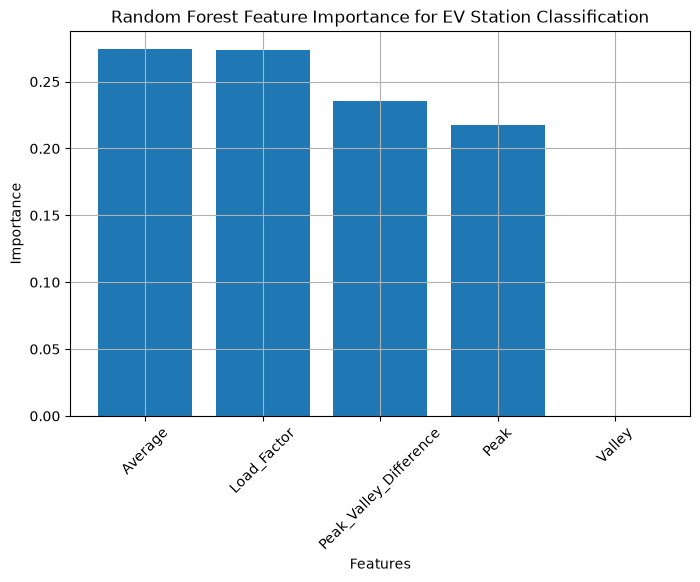

In [90]:
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "Random Forest Feature Importance for EV Station Classification"
)

plt.ylabel("Importance")
plt.xlabel("Features")

plt.xticks(rotation=45)
plt.grid(True)

plt.savefig(
    r"D:\Dataset\Anmol-MP-EV\figures\RF_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [91]:
import matplotlib.pyplot as plt
import pandas as pd

importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
3,Average,0.274189
4,Load_Factor,0.273363
2,Peak_Valley_Difference,0.235204
0,Peak,0.217244
1,Valley,0.000000


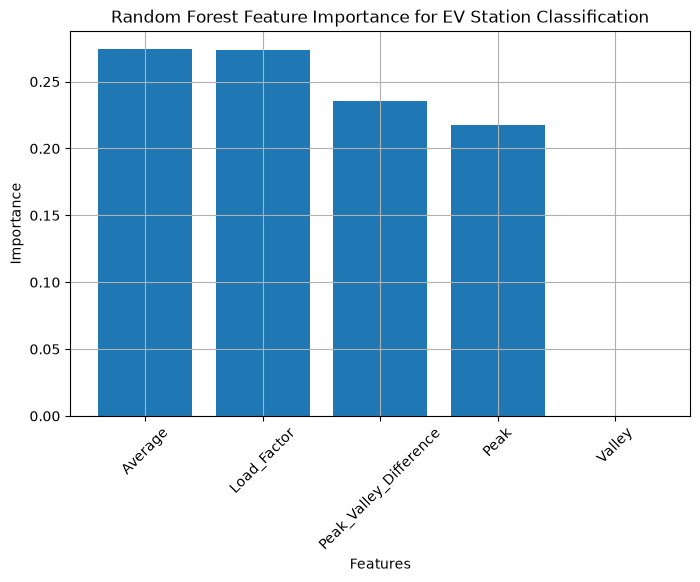

In [92]:
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title(
    "Random Forest Feature Importance for EV Station Classification"
)

plt.ylabel("Importance")
plt.xlabel("Features")

plt.xticks(rotation=45)
plt.grid(True)

plt.savefig(
    r"D:\Dataset\Anmol-MP-EV\figures\RF_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [95]:
import shap

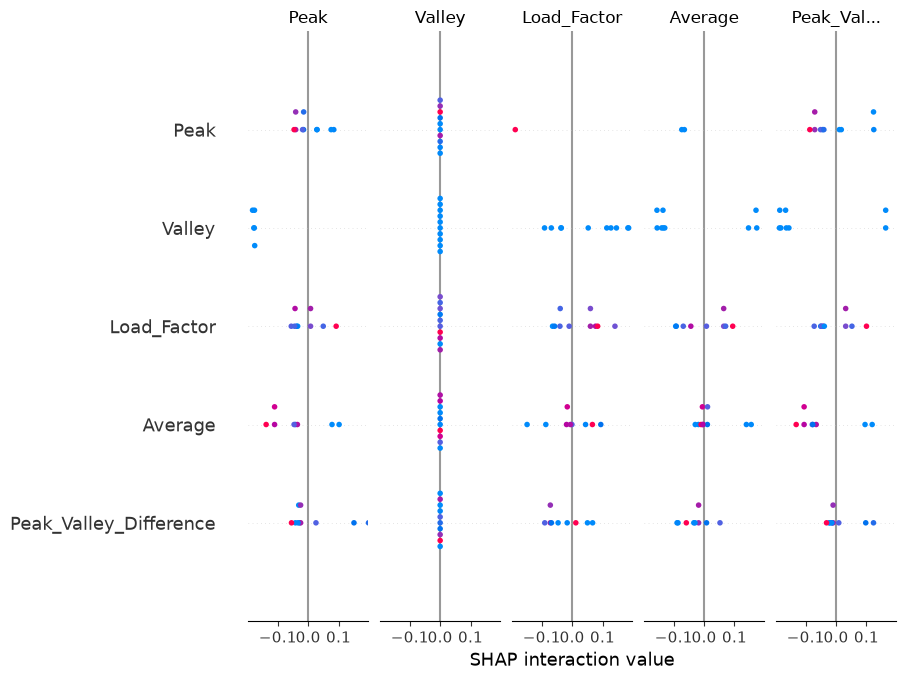

In [94]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)

shap.summary_plot(
    shap_values,
    X
)

In [96]:
plt.savefig(
    r"D:\Dataset\Anmol-MP-EV\figures\SHAP_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

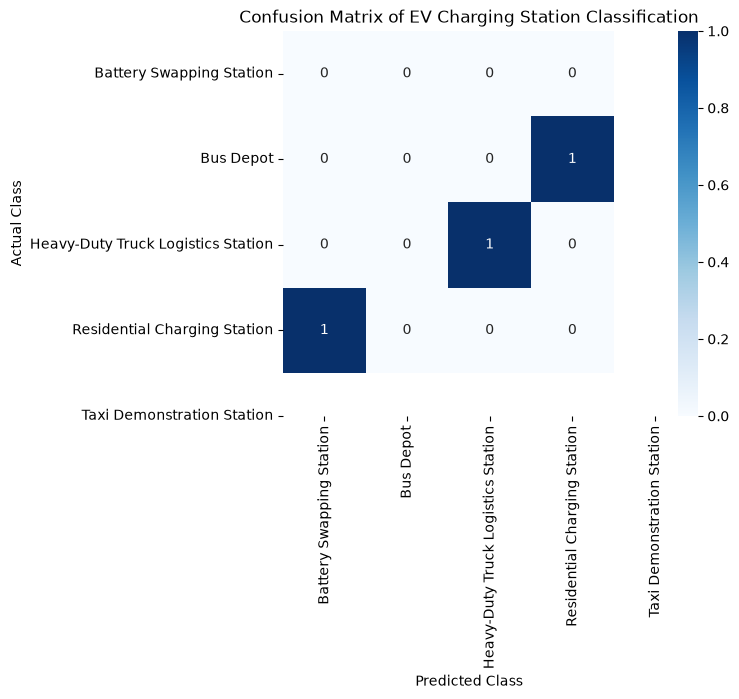

In [97]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix of EV Charging Station Classification")

plt.savefig(
    r"D:\Dataset\Anmol-MP-EV\figures\confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [98]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

model_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Value": [
        accuracy_score(y_test, prediction),
        precision_score(y_test, prediction, average="weighted"),
        recall_score(y_test, prediction, average="weighted"),
        f1_score(y_test, prediction, average="weighted")
    ]
})

model_results

C:\Users\Laptop Arena\anaconda3\envs\evresearch\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Laptop Arena\anaconda3\envs\evresearch\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Metric,Value
0,Accuracy,0.333333
1,Precision,0.333333
2,Recall,0.333333
3,F1-score,0.333333


In [99]:
model_results.to_csv(
    r"D:\Dataset\Anmol-MP-EV\processed_data\ML_model_performance.csv",
    index=False
)